# DICOM OCR & De-Identification with Visual NLP

This notebook walks through an end-to-end **medical-imaging de-identification** workflow built on John Snow Labs' **Visual NLP (Spark OCR)** and **Healthcare NLP** libraries. Works with **Spark-OCR 6.4.2** and above.

The notebook is organized in three parts:

1. **Image preparation** — decode the DICOM, compress the pixel data, and convert it into the annotation schema the Vision LLM expects.
2. **Blanket de-identification** — detect *every* text region on the image and black it all out. Maximum privacy, zero clinical-text retention.
3. **PHI-only de-identification** — run a clinical NER pipeline over the recognized text so that *only* protected health information (names, dates, IDs, ages, locations…) is redacted, leaving non-PHI text (e.g. anatomical labels) intact.

## 1 · Setup & imports

We pull in three layers of the John Snow Labs stack:

- **Visual NLP / Spark OCR** (`sparkocr.*`)
- **Spark NLP** (`sparknlp.*`) 
- **Healthcare NLP** (`sparknlp_jsl.*`) 

`Matplotlib` is required for display utilities to work.

In [1]:
from sparkocr import start
import os 

license = ""
secret = ""
nlp_secret = ""
aws_access_key = ""
aws_secret_key = ""

version = secret.split("-")[0]
spark_ocr_jar_path = "../../../target/scala-2.12"

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

spark = start(secret=secret, jar_path=spark_ocr_jar_path)

spark

Spark version: 3.4.1
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2



In [3]:
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *
from pyspark.ml import PipelineModel, Pipeline

from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel, Pipeline
from pyspark.ml.feature import SQLTransformer
import pkg_resources

import numpy as np
from PIL import Image
import io

### Load the Vision LLM — `MedicalVisionLLM`

`MedicalVisionLLM` is John Snow Labs' on-prem multimodal model served through a **llama.cpp / GGUF** backend. Here we load the pretrained `jsl-ocr-gguf-vlm1` **1-billon** checkpoint — a compact, OCR-focused VLM that reads an image plus a text prompt and returns recognized text **together with bounding-box coordinates**.

In [4]:
from sparkocr.transformers.medical_vision_llm import MedicalVisionLLM

model = MedicalVisionLLM.pretrained("jsl-ocr-gguf-vlm1", "en", "clinical/ocr") \
  .setInputCols(["caption_document", "image_assembler"]) \
  .setOutputCol("completions") \
  .setNGpuLayers(99) \
  .setNCtx(32768) \
  .setNParallel(1) \
  .setNBatch(2048) \
  .setNUbatch(1024) \
  .setNPredict(1024) \
  .setTemperature(0.01) \
  .setTopK(1) \
  .setTopP(1.0) \
  .setRepeatPenalty(1.03) \
  .setRepeatLastN(256) \
  .setStopStrings(["<\uff5chy_Assistant\uff5c>", "<\uff5chy_place\u2581holder\u2581no\u25812\uff5c>"]) \
  .setMinKeep(0) \
  .setNProbs(0) \
  .setOutputCol("completions") \
  .setBatchSize(1) \
  .setDisableLog(False)

jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB


### Read the DICOM & define the vision prompt

In [5]:
vision_prompt = "Detect and recognize text in the image, and output the text coordinates in a formatted manner."
path = "../data/dicom/David_Douglas.dcm"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(vision_prompt))
df.columns

17:00:07, INFO Error while sending or receiving.
Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.10/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer
17:00:07, INFO Closing down clientserver connection


['path', 'modificationTime', 'length', 'content', 'caption']

### DICOM → compressed image — `DicomToImageV3`

`DicomToImageV3` decodes the DICOM pixel data into a Spark OCR image annotation.

- `setInputCols(["content"])` reads the raw bytes; `setOutputCol("image")` writes the image struct.
- `setCompressImage(True)` returns the raw bytes in `Image.data`.
- `setCompressionMode("enabled")` enables compression.
- `setCompressionQuality(80)` applies JPEG compression at the given quality.
- `setMemoryOptimized(True)` memory optimized transformation.
- `setKeepInput(False)` drops the original binary once the image is produced.

Together these reduce the memory footprint of the decoded image.

In [6]:
scale = .5
dicom_to_image = DicomToImageV3() \
    .setInputCols(["content"]) \
    .setOutputCol("image") \
    .setCompressImage(True) \
    .setCompressionMode("enabled") \
    .setKeepInput(False) \
    .setMemoryOptimized(True) \
    .setCompressionQuality(80) \
    .setScale(scale)


17:00:07, INFO Exception while sending command.
Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.10/site-packages/py4j/clientserver.py", line 503, in send_command
    self.socket.sendall(command.encode("utf-8"))
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jose/.local/lib/python3.10/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/jose/.local/lib/python3.10/site-packages/py4j/clientserver.py", line 506, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending
17:00:08, INFO Closing down clientserver connection


In [7]:
result = dicom_to_image.transform(df)
result.columns

/home/jose/.local/lib/python3.10/site-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


['image',
 'exception',
 'pagenum',
 'frame_dims',
 'path',
 'modificationTime',
 'length',
 'caption']

In [8]:
result.select("path", col("frame_dims").alias("Image Dimensions"), col("caption")).show(10, False)

+-----------------------------------------------------------------------+----------------+----------------------------------------------------------------------------------------------+
|path                                                                   |Image Dimensions|caption                                                                                       |
+-----------------------------------------------------------------------+----------------+----------------------------------------------------------------------------------------------+
|file:/home/jose/spark-ocr/workshop/jupyter/data/dicom/David_Douglas.dcm|{1070, 880}     |Detect and recognize text in the image, and output the text coordinates in a formatted manner.|
+-----------------------------------------------------------------------+----------------+----------------------------------------------------------------------------------------------+



### Match the VLM's image schema — `ImageSchemaConverter`

The VLM does not read the internal Spark OCR image struct directly — it expects the **assembler** annotation schema.

`ImageSchemaConverter` bridges the two representations:

- `setOutputSchema(ImageSchemaConversion.ASSEMBLER)` converts the internal compressed image struct → VLM / assembler format.
- The reverse direction (`ImageSchemaConversion.INTERNAL`) converts an assembler image back to the internal struct.
- `setKeepInput(True)` keeps the original `image` column alongside the new `image_assembler` column (handy for previewing).

Both stages are wrapped in a `PipelineModel` so they run together.

In [9]:
dicom_to_image = DicomToImageV3() \
    .setInputCols(["content"]) \
    .setOutputCol("image") \
    .setCompressImage(True) \
    .setCompressionMode("enabled") \
    .setKeepInput(False) \
    .setMemoryOptimized(True) \
    .setCompressionQuality(80)

schema_converter = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(True)

pipeline = PipelineModel(stages=[
    dicom_to_image,
    schema_converter
])

In [10]:
result = pipeline.transform(df)
result.columns

['image',
 'exception',
 'pagenum',
 'frame_dims',
 'path',
 'modificationTime',
 'length',
 'caption',
 'image_assembler']

### Inspect the two image schemas

Printing the schemas side-by-side shows the internal compressed `image` struct vs. the `image_assembler` annotation array the VLM will consume.

In [11]:
result.select("image", "image_assembler",).printSchema()

root
 |-- image: struct (nullable = true)
 |    |-- origin: string (nullable = true)
 |    |-- height: integer (nullable = false)
 |    |-- width: integer (nullable = false)
 |    |-- nChannels: integer (nullable = false)
 |    |-- mode: integer (nullable = false)
 |    |-- resolution: integer (nullable = false)
 |    |-- data: binary (nullable = true)
 |-- image_assembler: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- origin: string (nullable = false)
 |    |    |-- height: integer (nullable = false)
 |    |    |-- width: integer (nullable = false)
 |    |    |-- nChannels: integer (nullable = false)
 |    |    |-- mode: integer (nullable = false)
 |    |    |-- result: binary (nullable = false)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = true)
 |    |    |-- text: string (nullable = true)



### Preview the decoded image

`display_images` renders the `image` column inline so you can confirm the DICOM decoded correctly — and see the burned-in text we're about to redact.


    Image #0:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/dicom/David_Douglas.dcm
    Resolution: 0 dpi
    Width: 2140 px
    Height: 1760 px
    Mode: ImageType.TYPE_JPEG
    Number of channels: 1


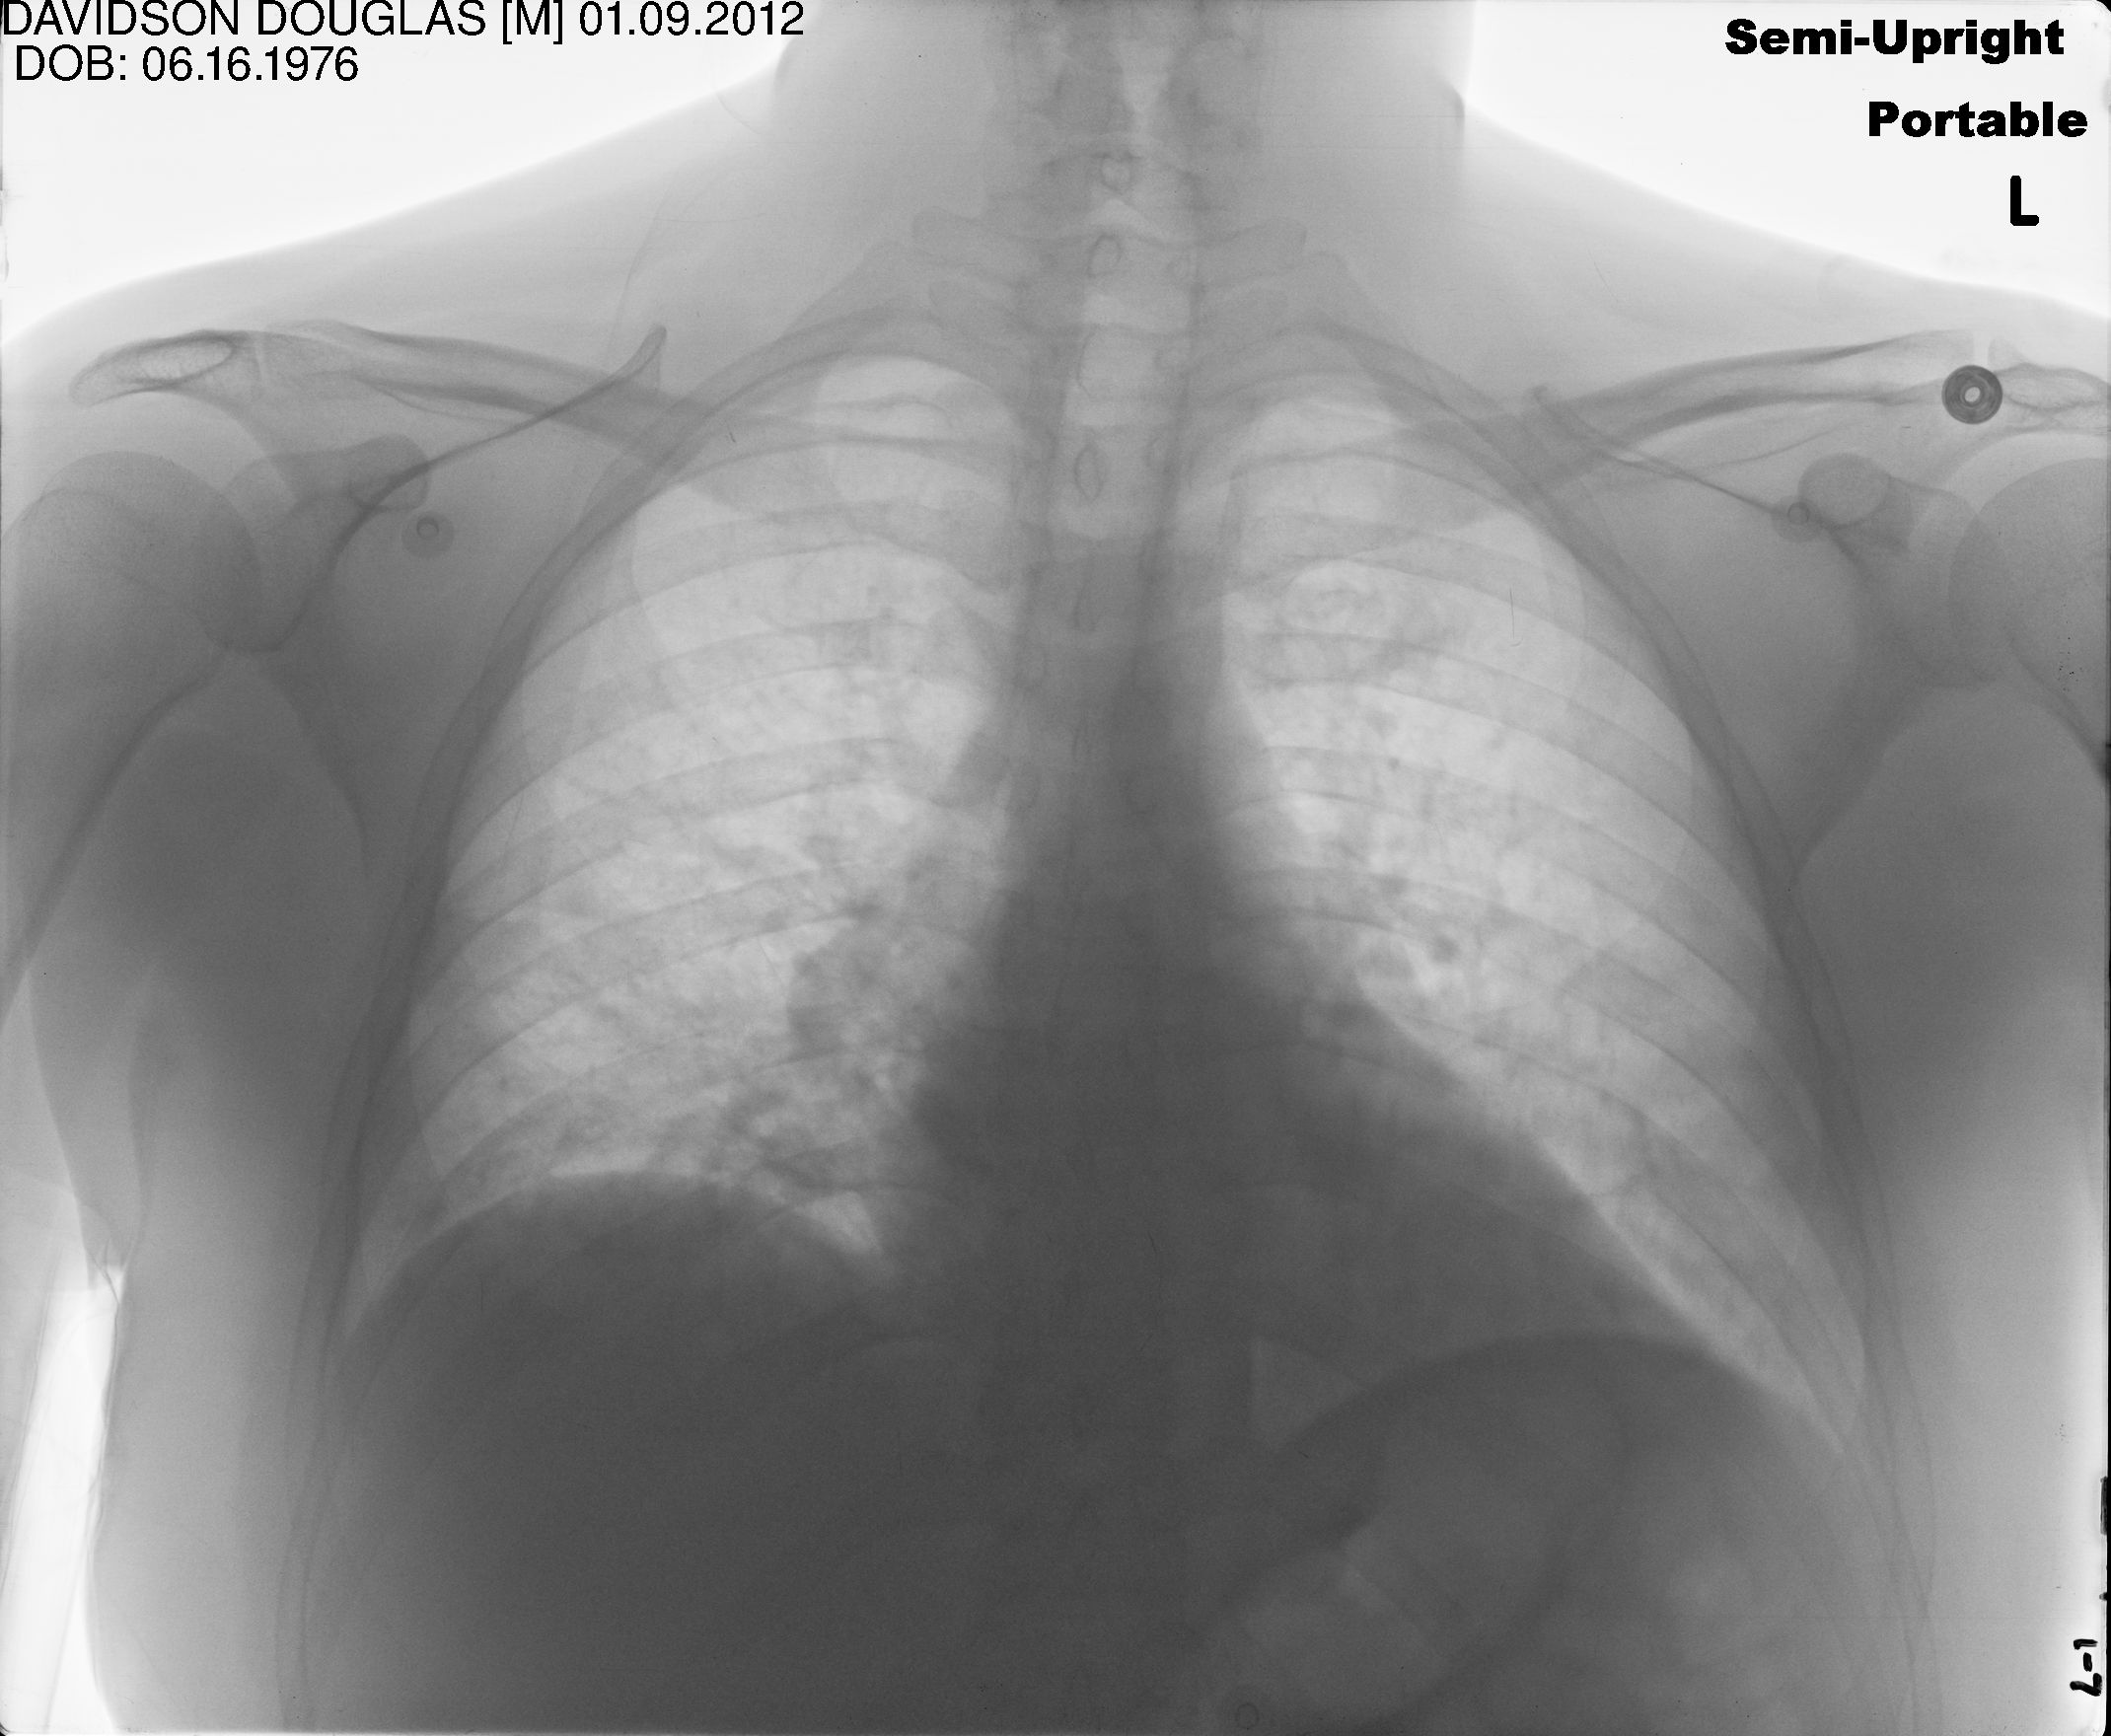

In [12]:
display_images(df=result, field="image", limit=1, width=200, show_meta=True)

## 2 · Blanket de-identification

The simplest, most conservative strategy: **redact everything the OCR finds.** No clinical NER is involved — if the VLM saw text there, we black it out.

Flow:

1. **`DicomToImageV3`** — decode the DICOM.
2. **`DocumentAssembler`** on `caption` — wrap the prompt as a `caption_document` annotation.
3. **`ImageSchemaConverter`** — produce `image_assembler` for the VLM.
4. **`MedicalVisionLLM`** — emit recognized text + coordinates into `completions`.
5. **`DocumentCoordinatesToText`** — the bridge from the VLM's raw text output back into the image's geometry. 
6. **`DicomDrawRegions`** — burn opaque boxes over every region directly onto the DICOM pixel data.

In [13]:
dicom_to_image = DicomToImageV3() \
    .setInputCols(["content"]) \
    .setOutputCol("image") \
    .setCompressImage(True) \
    .setCompressionMode("enabled") \
    .setKeepInput(False) \
    .setMemoryOptimized(True) \
    .setCompressionQuality(80)

caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema("assembler") \
    .setKeepInput(False)

coordinate_extract = DocumentCoordinatesToText() \
    .setInputCol("completions") \
    .setImageDimsCol("frame_dims") \
    .setOutputCol("text") \
    .setPageMatrixCol("positions") \
    .setRegionCol("regions")

draw_regions = DicomDrawRegions() \
    .setInputCol("path") \
    .setInputRegionsCol("regions") \
    .setOutputCol("dicom") \
    .setAggCols(["path"]) \
    .setKeepInput(True) \
    .setScaleFactor(1 / scale)

pipeline = PipelineModel(stages=[
    dicom_to_image,
    caption_assembler,
    schema_converter_assembler,
    model,
    coordinate_extract,
    draw_regions
])

In [14]:
result = pipeline.transform(df)
result.columns

['dicom', 'exception', 'path']

### Render the redacted DICOM

`display_dicom` shows the output DICOM with every detected text region blacked out.

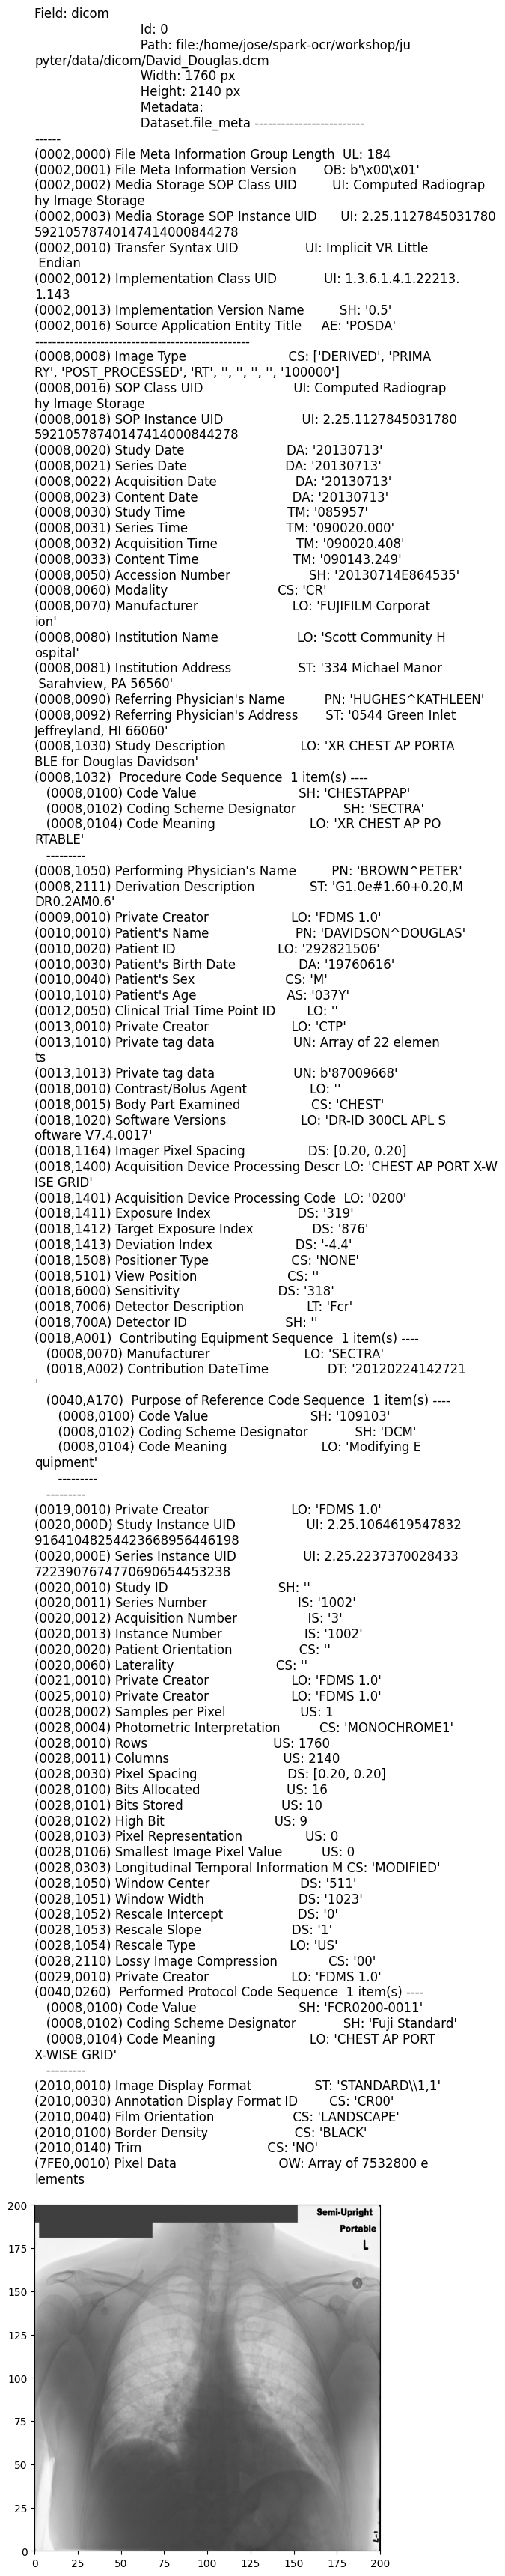

In [15]:
display_dicom(df=result, fields="dicom", limit=1, width=300)

## 3 · PHI-only de-identification

Blanking everything is safe but destroys useful non-PHI text (orientation markers, anatomical labels, technique notes). The PHI-only approach is **selective**: run the recognized OCR text through John Snow Labs' clinical **de-identification NER**, and redact *only* the text classified as protected health information.

In [16]:
def deidentification_nlp_pipeline(input_column, prefix = "", model="ner_deid_large"):
    """
    Basic NLP DeIdentification Pipeline
    """
    document_assembler = DocumentAssembler() \
        .setInputCol(input_column) \
        .setOutputCol(prefix + "document_raw")

    cleanUpPatterns = ["<[^>]>"]
    documentNormalizer = DocumentNormalizer() \
      .setInputCols(prefix + "document_raw") \
      .setOutputCol(prefix + "document") \
      .setAction("clean") \
      .setPatterns(cleanUpPatterns) \
      .setReplacement(" ") \
      .setPolicy("pretty_all")

    sentence_detector = SentenceDetector() \
        .setInputCols([prefix + "document"]) \
        .setOutputCol(prefix + "sentence")

    tokenizer = Tokenizer() \
        .setInputCols([prefix + "sentence"]) \
        .setOutputCol(prefix + "token")

    word_embeddings = WordEmbeddingsModel.pretrained("embeddings_clinical", "en", "clinical/models") \
        .setInputCols([prefix + "sentence", prefix + "token"]) \
        .setOutputCol(prefix + "embeddings")

    clinical_ner = MedicalNerModel.pretrained(model, "en", "clinical/models") \
        .setInputCols([prefix + "sentence", prefix + "token", prefix + "embeddings"]) \
        .setOutputCol(prefix + "ner")

    custom_ner_converter = NerConverter() \
        .setInputCols([prefix + "sentence", prefix + "token", prefix + "ner"]) \
        .setOutputCol(prefix + "ner_chunk") \
        .setWhiteList(['NAME', 'AGE', 'CONTACT',
                   'LOCATION', 'PROFESSION', 'PERSON', 'DATE', 'ID','DOCTOR'])

    date_regex_matcher = RegexMatcherInternalModel.pretrained("date_matcher","en","clinical/models") \
        .setInputCols(["sentence"]) \
        .setOutputCol("date_chunk")

    chunk_merger = ChunkMergeApproach()\
        .setInputCols('ner_chunk', "date_chunk")\
        .setOutputCol('merged_chunk')\
        .setMergeOverlapping(True)

    nlp_pipeline = Pipeline(stages=[
        document_assembler,
        documentNormalizer,
        sentence_detector,
        tokenizer,
        word_embeddings,
        clinical_ner,
        custom_ner_converter,
        date_regex_matcher,
        chunk_merger
        ])

    empty_data = spark.createDataFrame([[""]]).toDF(input_column)
    nlp_model = nlp_pipeline.fit(empty_data)
    return nlp_model

### Assemble the full PHI-only pipeline

This combines the image stages, the VLM, the de-id sub-pipeline, and two coordinate stages:

`draw_regions` is intentionally left out of the fitted pipeline here so we can inspect the intermediate text / regions / chunks first, then apply it manually in the last cell.

In [17]:
dicom_to_image = DicomToImageV3() \
    .setInputCols(["content"]) \
    .setOutputCol("image") \
    .setCompressImage(True) \
    .setCompressionMode("enabled") \
    .setKeepInput(False) \
    .setMemoryOptimized(True) \
    .setCompressionQuality(80) \
    .setScale(scale)

caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema("assembler") \
    .setKeepInput(False)

coordinate_extract = DocumentCoordinatesToText() \
    .setInputCol("completions") \
    .setImageDimsCol("frame_dims") \
    .setOutputCol("text") \
    .setPageMatrixCol("positions") \
    .setRegionCol("regions")

position_finder = PositionFinder() \
    .setInputCols(["merged_chunk"]) \
    .setOutputCol("coordinates") \
    .setPageMatrixCol("positions") \
    .setIgnoreSchema(True) \
    .setOcrScaleFactor(1.0)

draw_regions = DicomDrawRegions() \
    .setInputCol("path") \
    .setInputRegionsCol("coordinates") \
    .setOutputCol("dicom") \
    .setAggCols(["path"]) \
    .setKeepInput(True) \
    .setScaleFactor(1 / scale)

pipeline = PipelineModel(stages=[
    dicom_to_image,
    caption_assembler,
    schema_converter_assembler,
    model,
    coordinate_extract,
    deidentification_nlp_pipeline(input_column="text", prefix="", model="ner_deid_sd"),
    position_finder,
    # excluded so we can inspect intermediate results before redacting
    #draw_regions
])

embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
ner_deid_sd download started this may take some time.
Approximate size to download 14 MB
[OK!]
date_matcher download started this may take some time.
Approximate size to download 2.4 KB
[OK!]


In [18]:
result = pipeline.transform(df)
result.columns

/home/jose/.local/lib/python3.10/site-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


['exception',
 'pagenum',
 'frame_dims',
 'path',
 'modificationTime',
 'length',
 'caption',
 'caption_document',
 'image_assembler',
 'completions',
 'text',
 'regions',
 'positions',
 'document_raw',
 'document',
 'sentence',
 'token',
 'embeddings',
 'ner',
 'ner_chunk',
 'date_chunk',
 'merged_chunk',
 'coordinates']

### Inspect intermediate results

Before redacting, sanity-check each stage:

- `text` — the raw OCR output the VLM produced.
- `regions` — the geometry `DocumentCoordinatesToText` recovered.
- `merged_chunk` — the PHI spans the de-id NER + date matcher flagged. **This is what will actually be redacted.**

In [19]:
result.select(F.col("text").alias("Detected Text")).show(10, False)

+----------------------------------------------------------------------------+
|Detected Text                                                               |
+----------------------------------------------------------------------------+
|DAVIDSON DOUGLAS [M] 01.09.2012 Semi-Upright DOB: 06.16.1976\nPortable\nL\nT|
+----------------------------------------------------------------------------+



In [20]:
result.select(F.explode("regions").alias("Detected Text Regions")).show(10, False)

+----------------------------------------------------------------------+
|Detected Text Regions                                                 |
+----------------------------------------------------------------------+
|{0, 0, 0.0, 0.0, 408.74, 22.880001, 0.0, VLM_V1, 0.0, false}          |
|{1, 0, 872.05, 6.16, 174.40997, 27.279999, 0.0, VLM_V1, 0.0, false}   |
|{2, 0, 5.35, 22.0, 176.54999, 20.240002, 0.0, VLM_V1, 0.0, false}     |
|{3, 0, 945.88, 49.28, 112.349976, 21.120003, 0.0, VLM_V1, 0.0, false} |
|{4, 0, 1016.5, 87.12, 18.190063, 28.159996, 0.0, VLM_V1, 0.0, false}  |
|{5, 0, 1047.53, 828.96, 21.400024, 29.919983, 0.0, VLM_V1, 0.0, false}|
+----------------------------------------------------------------------+



In [21]:
result.select(F.explode("merged_chunk").alias("Detected PHI Chunk")).show(10, False)

+--------------------------------------------------------------------------------------------------------+
|Detected PHI Chunk                                                                                      |
+--------------------------------------------------------------------------------------------------------+
|{chunk, 0, 15, DAVIDSON DOUGLAS, {entity -> NAME, confidence -> 0.94855, chunk -> 0, sentence -> 0}, []}|
|{chunk, 21, 30, 01.09.2012, {entity -> CONTACT, confidence -> 0.4558, chunk -> 1, sentence -> 0}, []}   |
|{chunk, 50, 59, 06.16.1976, {entity -> DATE, ner_source -> date_chunk, chunk -> 2, sentence -> 0}, []}  |
+--------------------------------------------------------------------------------------------------------+



### Apply redaction & render

Finally, run `DicomDrawRegions` over the result and display the DICOM with **only the PHI** boxed out — non-PHI text remains readable.

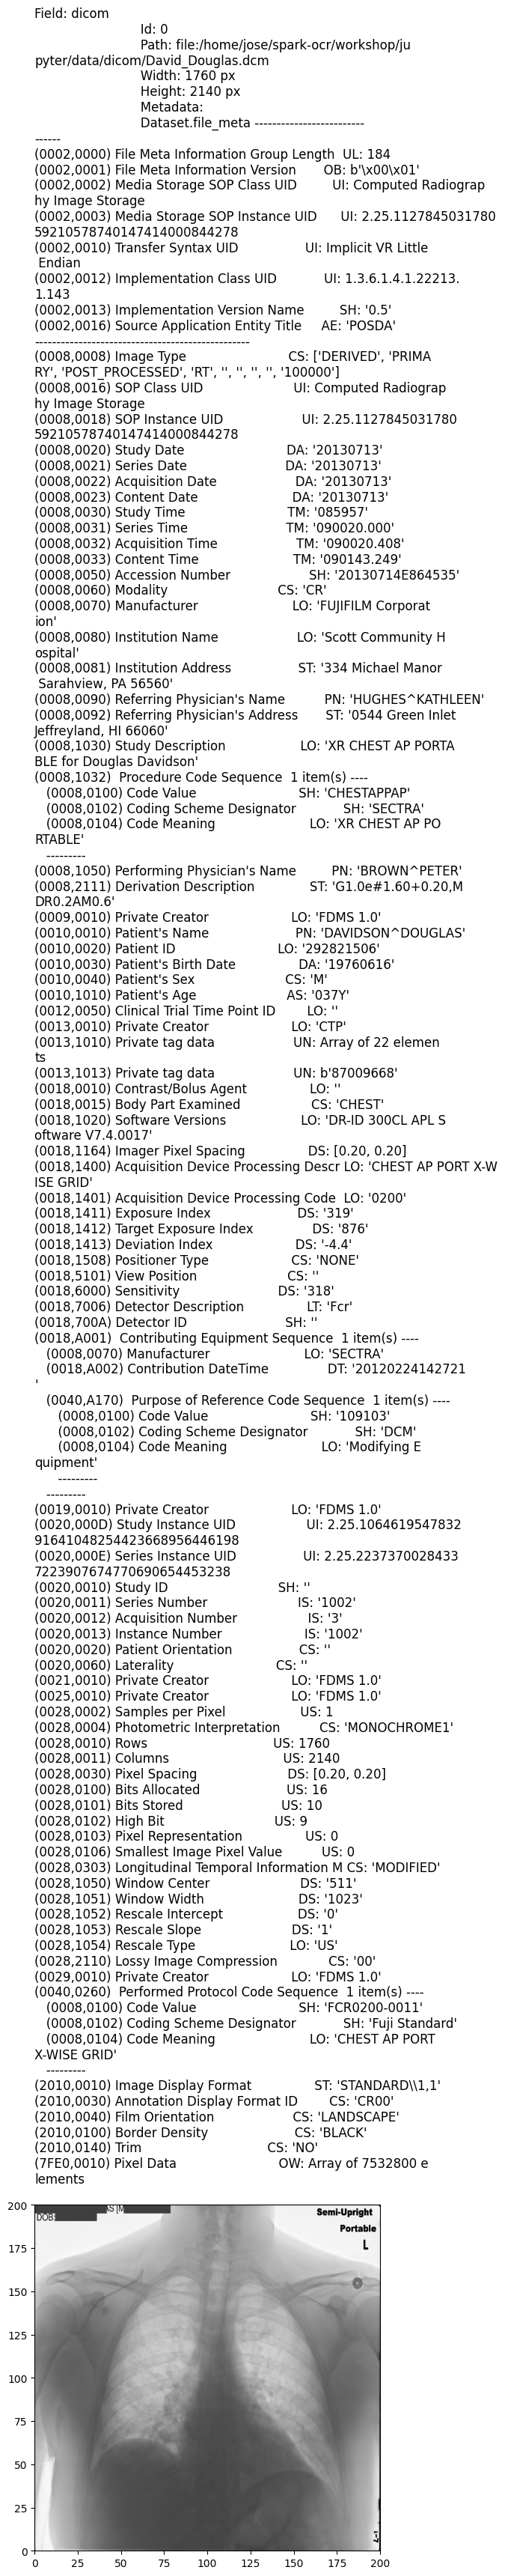

In [22]:
dicom_draw_res = draw_regions.transform(result)

display_dicom(df=dicom_draw_res, fields="dicom", limit=1, width=300)